In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

In [2]:
df = pd.read_csv("../data/MachineLearningRating_v3.txt", sep="|")
df.head()

C:\Users\YOGA 9I\AppData\Local\Temp\ipykernel_6448\455118313.py:1: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/MachineLearningRating_v3.txt", sep="|")


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [16]:
print("Shape:", df.shape)
df.info()

Shape: (1000098, 54)
<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 54 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   UnderwrittenCoverID       1000098 non-null  int64         
 1   PolicyID                  1000098 non-null  int64         
 2   TransactionMonth          1000098 non-null  datetime64[us]
 3   IsVATRegistered           1000098 non-null  bool          
 4   Citizenship               1000098 non-null  str           
 5   LegalType                 1000098 non-null  str           
 6   Title                     1000098 non-null  str           
 7   Language                  1000098 non-null  str           
 8   Bank                      854137 non-null   str           
 9   AccountType               959866 non-null   str           
 10  MaritalStatus             991839 non-null   str           
 11  Gender                    990562 non-nul

In [17]:
df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"])
df["VehicleIntroDate"] = pd.to_datetime(df["VehicleIntroDate"], errors="coerce")

In [18]:
df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]
df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

In [19]:
df.describe()

c:\Users\YOGA 9I\Downloads\climate-challenge-week0\venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,UnderwrittenCoverID,PolicyID,TransactionMonth,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims,LossRatio,Margin
count,1.000098e+06,1.000098e+06,1000098,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,999546,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,618614.0,1.000098e+06
mean,1.048175e+05,7.956682e+03,2015-02-28 10:49:29.147424,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2008-04-20 17:04:04.990425,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01,NaN,-2.955694e+00
min,1.000000e+00,1.400000e+01,2013-10-01 00:00:00,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,1977-10-01 00:00:00,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04,-inf,-3.928486e+05
25%,5.514300e+04,4.500000e+03,2015-01-01 00:00:00,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,2007-11-01 00:00:00,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00
50%,9.408300e+04,7.071000e+03,2015-04-01 00:00:00,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2010-10-01 00:00:00,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00,0.0,2.157687e+00
75%,1.391900e+05,1.107700e+04,2015-06-01 00:00:00,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2012-04-01 00:00:00,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00,0.0,2.192982e+01
max,3.011750e+05,2.324600e+04,2015-08-01 00:00:00,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2014-09-01 00:00:00,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05,inf,6.528260e+04
std,6.329371e+04,5.290039e+03,NaN,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,NaN,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03,NaN,2.367137e+03


In [20]:
df.describe(include="object")

C:\Users\YOGA 9I\AppData\Local\Temp\ipykernel_6448\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,...,CrossBorder,TermFrequency,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType
count,1000098,1000098,1000098,1000098,854137,959866,991839,990562,1000098,1000098,...,698,1000098,1000098,1000098,1000098,1000098,1000098,1000098,1000098,1000098
unique,4,6,5,1,11,3,3,3,1,9,...,1,2,13,28,22,14,5,4,1,1
top,,Individual,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,...,No,Monthly,No excess,Passenger Liability,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant
freq,895210,911929,933555,1000098,260811,597938,986208,940990,1000098,393865,...,698,999554,791235,104158,104183,824124,828125,915028,1000098,1000098


In [21]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
Converted                   641901
WrittenOff                  641901
Rebuilt                     641901
LossRatio                   381484
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
NumberOfDoors                  552
VehicleIntroDate               552
VehicleType                    552
cubiccapacity                  552
Model                          552
Cylinders                      552
kilowatts                      552
bodytype                       552
mmcode                         552
make                           552
CapitalOutstanding               2
dtype: int64

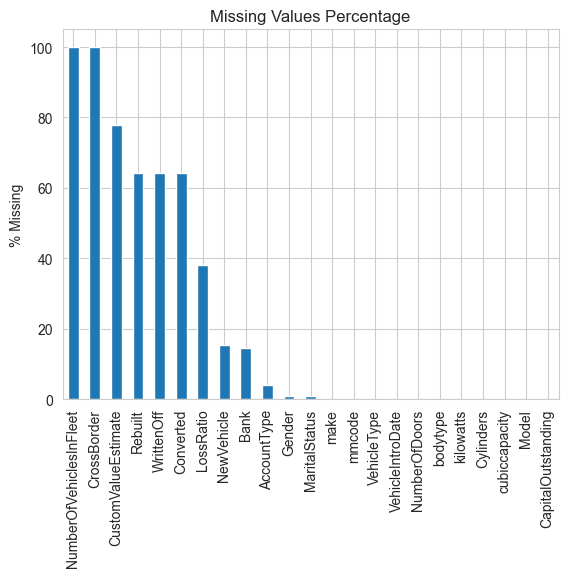

In [22]:
missing_pct = (df.isnull().sum()/len(df))*100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

missing_pct.plot(kind="bar")
plt.title("Missing Values Percentage")
plt.ylabel("% Missing")
plt.show()

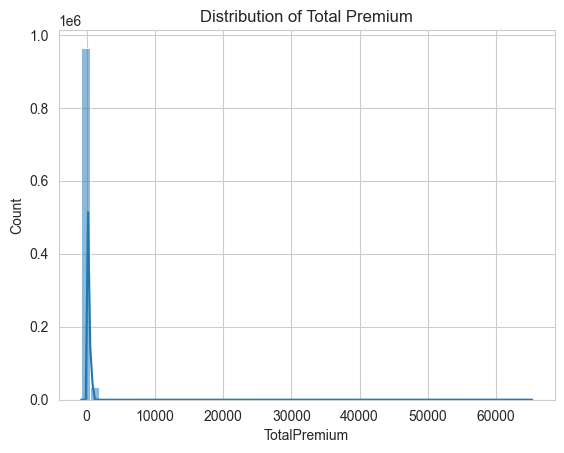

In [23]:
sns.histplot(df["TotalPremium"], bins=50, kde=True)
plt.title("Distribution of Total Premium")
plt.show()

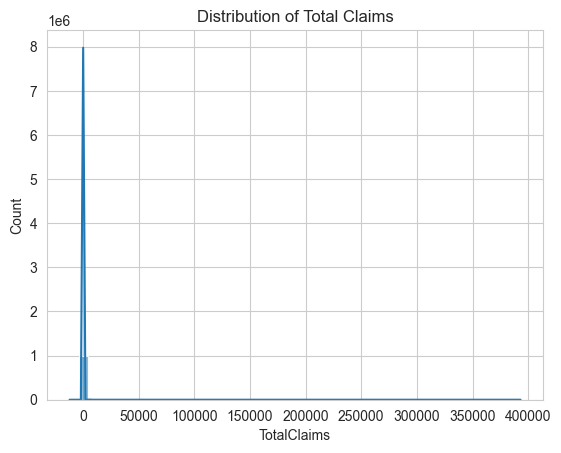

In [24]:
sns.histplot(df["TotalClaims"], bins=50, kde=True)
plt.title("Distribution of Total Claims")
plt.show()

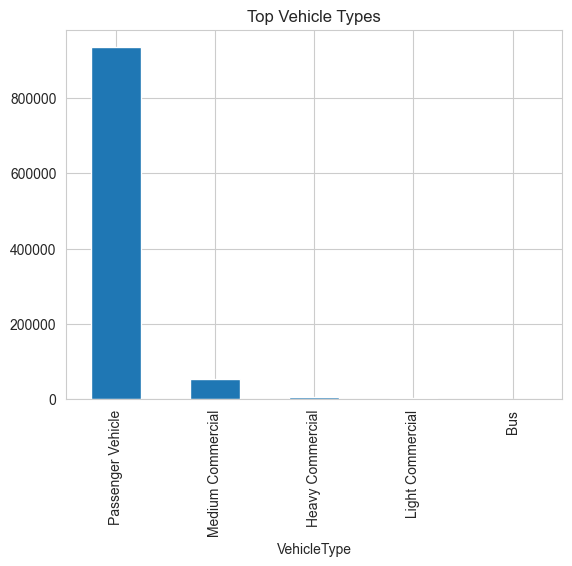

In [25]:
df["VehicleType"].value_counts().head(10).plot(kind="bar")
plt.title("Top Vehicle Types")
plt.show()

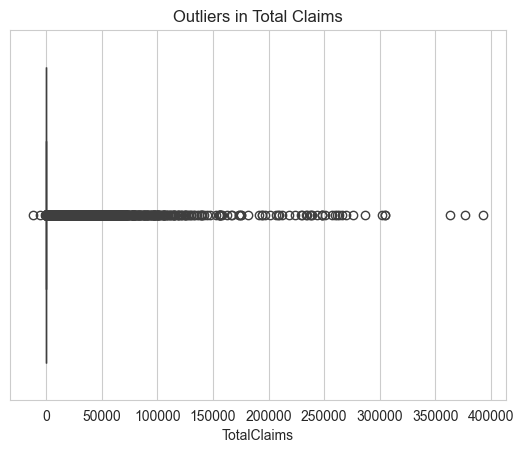

In [26]:
sns.boxplot(x=df["TotalClaims"])
plt.title("Outliers in Total Claims")
plt.show()

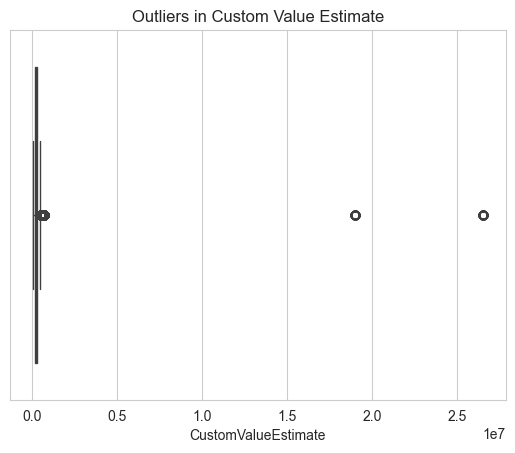

In [27]:
sns.boxplot(x=df["CustomValueEstimate"])
plt.title("Outliers in Custom Value Estimate")
plt.show()

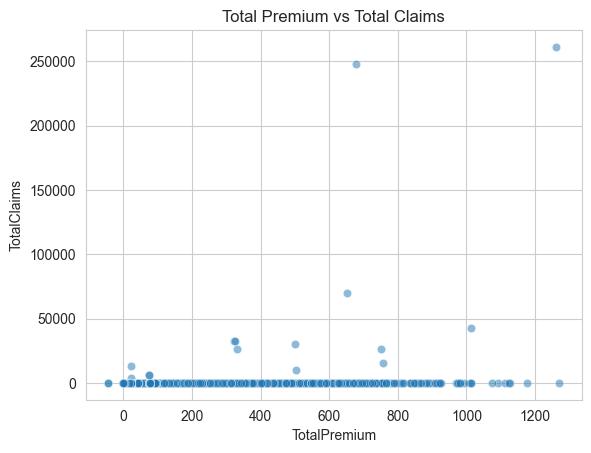

In [28]:
sns.scatterplot(
    data=df.sample(5000),
    x="TotalPremium",
    y="TotalClaims",
    alpha=0.5
)

plt.title("Total Premium vs Total Claims")
plt.show()

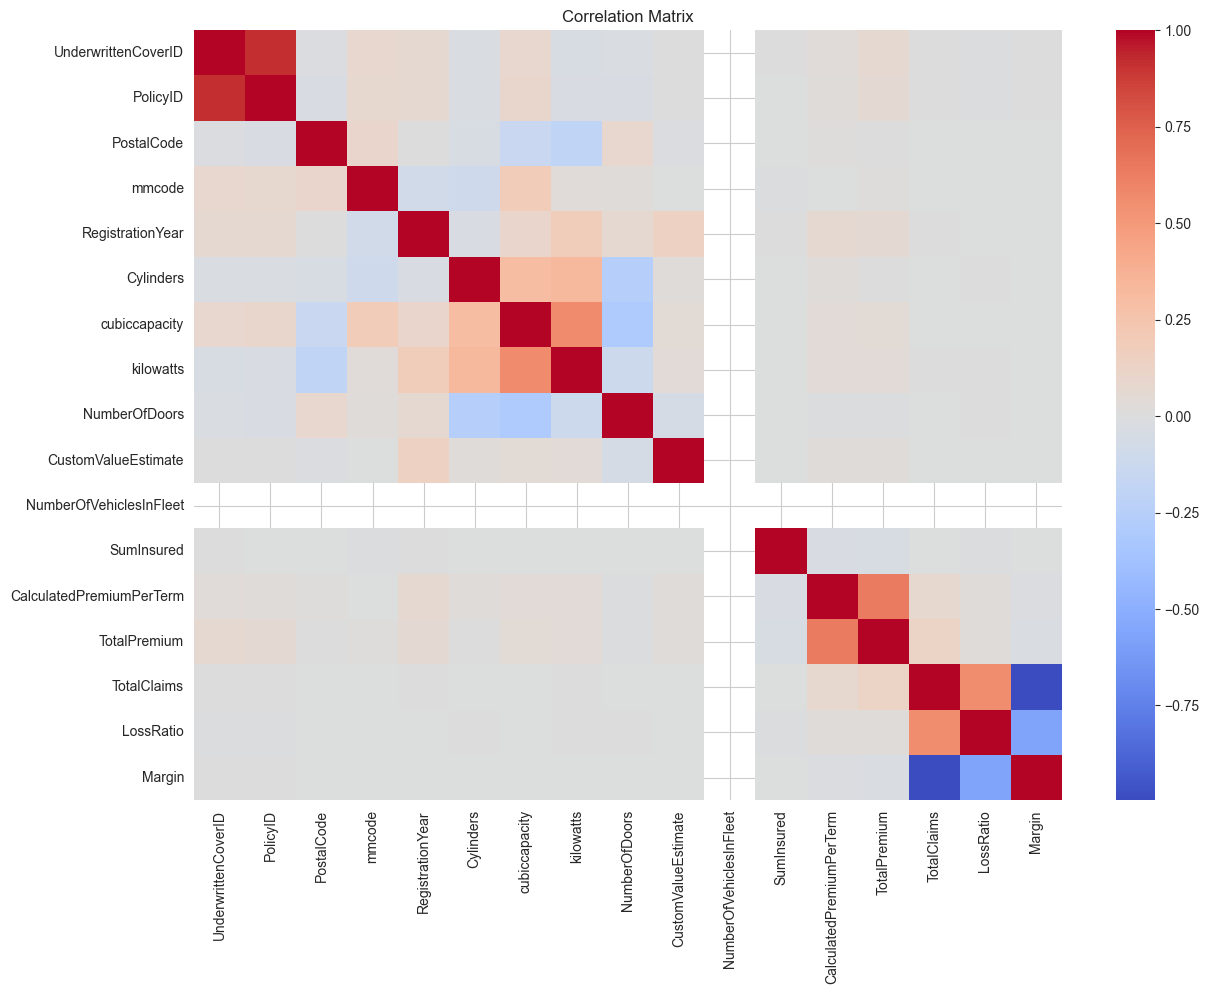

In [29]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

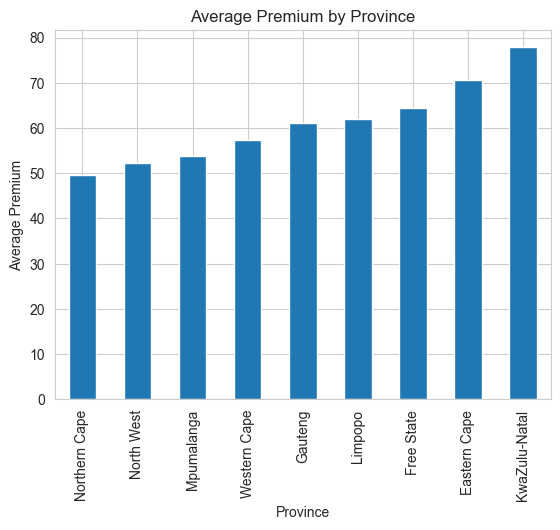

In [30]:
df.groupby("Province")["TotalPremium"].mean().sort_values().plot(kind="bar")
plt.title("Average Premium by Province")
plt.ylabel("Average Premium")
plt.show()

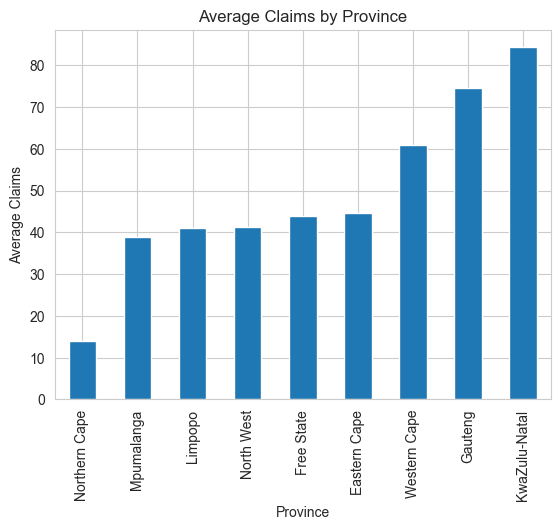

In [31]:
df.groupby("Province")["TotalClaims"].mean().sort_values().plot(kind="bar")
plt.title("Average Claims by Province")
plt.ylabel("Average Claims")
plt.show()

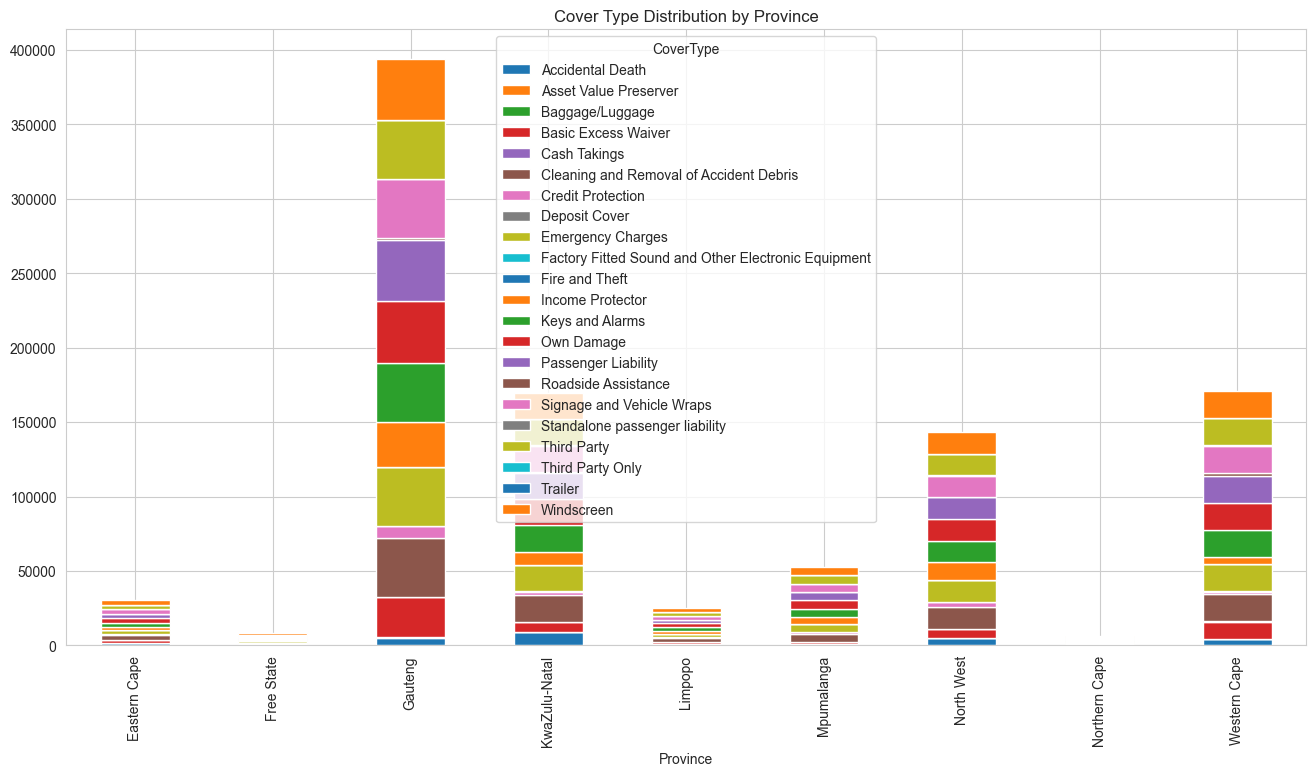

In [32]:
province_cover = pd.crosstab(df["Province"], df["CoverType"])

province_cover.plot(kind="bar", stacked=True, figsize=(16,8))
plt.title("Cover Type Distribution by Province")
plt.show()

In [33]:
overall_loss_ratio = df["TotalClaims"].sum() / df["TotalPremium"].sum()
print("Overall Loss Ratio:", overall_loss_ratio)

Overall Loss Ratio: 1.0477452570332206


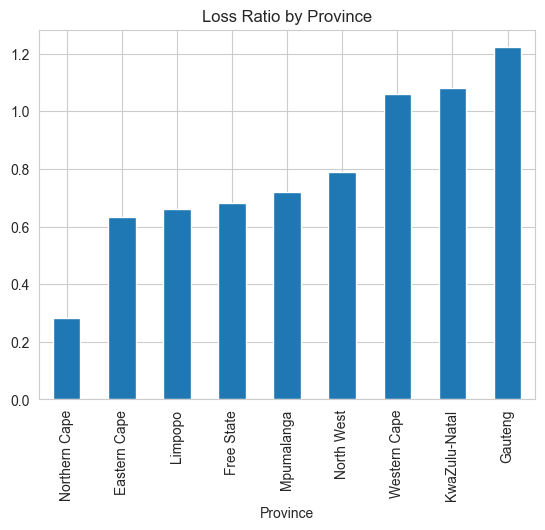

In [34]:
province_lr = df.groupby("Province").apply(
    lambda x: x["TotalClaims"].sum()/x["TotalPremium"].sum()
)

province_lr.sort_values().plot(kind="bar")
plt.title("Loss Ratio by Province")
plt.show()

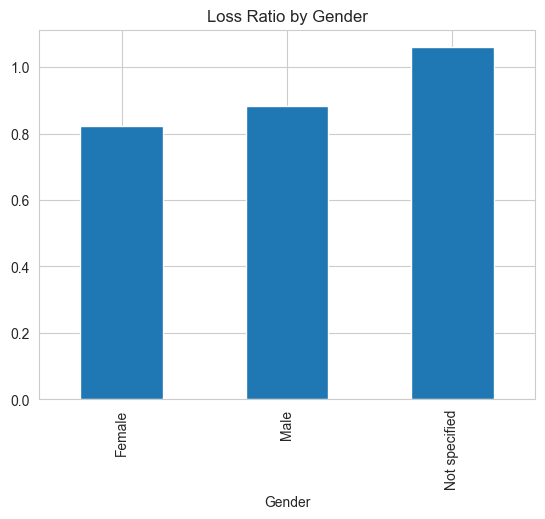

In [35]:
gender_lr = df.groupby("Gender").apply(
    lambda x: x["TotalClaims"].sum()/x["TotalPremium"].sum()
)

gender_lr.plot(kind="bar")
plt.title("Loss Ratio by Gender")
plt.show()

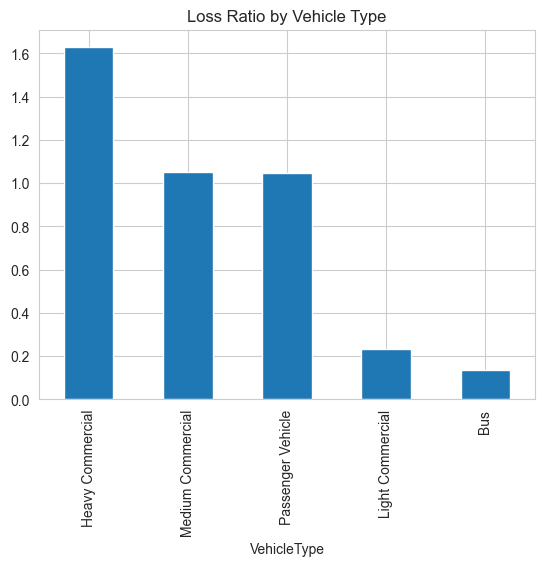

In [36]:
vehicle_lr = df.groupby("VehicleType").apply(
    lambda x: x["TotalClaims"].sum()/x["TotalPremium"].sum()
)

vehicle_lr.sort_values(ascending=False).head(15).plot(kind="bar")
plt.title("Loss Ratio by Vehicle Type")
plt.show()

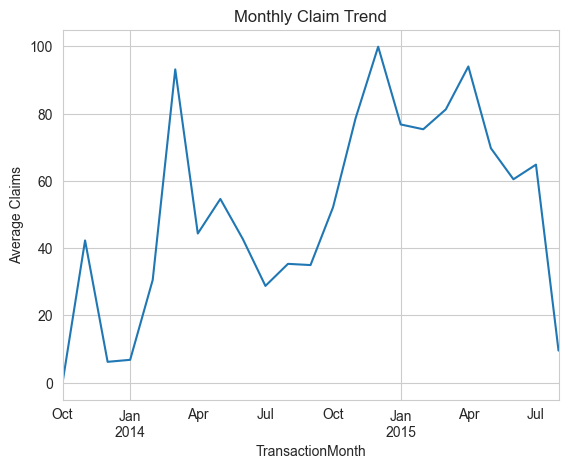

In [37]:
monthly_claims = df.groupby("TransactionMonth")["TotalClaims"].mean()

monthly_claims.plot()
plt.title("Monthly Claim Trend")
plt.ylabel("Average Claims")
plt.show()

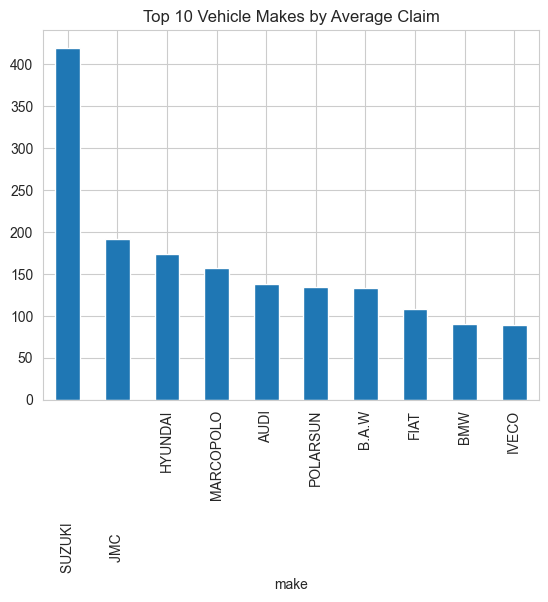

In [38]:
top_claim_makes = df.groupby("make")["TotalClaims"].mean().sort_values(ascending=False).head(10)

top_claim_makes.plot(kind="bar")
plt.title("Top 10 Vehicle Makes by Average Claim")
plt.show()